# 11. XGBoost от начала до конца: цены квартир, 20 000 объектов

| | |
|---|---|
| **Уровень** | 3 из 4 — средние данные: полный цикл и типовые случаи (`3_medium`) |
| **Скрипт-источник** | [`11_xgboost_complete.py`](../11_xgboost_complete.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 4 с |

**Цель.** Полный рабочий цикл XGBoost на смешанных табличных данных.

### Чему вы научитесь

- Категории (`enable_categorical`)
- Пропуски «как есть»
- sklearn-интерфейс и нативный `xgb.train`
- Ранняя остановка и `best_iteration`
- Логарифм цели
- Важности gain и weight
- Вклады признаков (`pred_contribs`)
- Сохранение в JSON и загрузка

### Данные

`_data.make_houses` — 20 000 квартир, 10 признаков: площадь, комнаты, этаж, этажность, год, расстояние до центра, район (30 значений), парковка, ремонт (категория), кухня (5% пропусков); цель — цена, млн.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Разбиение 60 / 20 / 20: обучение, валидация (остановка), тест (итог)
3. **Этап 3.** XGBRegressor: категории и пропуски без подготовки, ранняя остановка
4. **Этап 4.** Цены распределены с длинным хвостом — обучаем на log(цены)
5. **Этап 5.** Нативный интерфейс: DMatrix + xgb.train — то же самое, но с полным контролем
6. **Этап 6.** Важности (gain против weight) и вклады признаков для одной квартиры
7. **Этап 7.** Сохранение в JSON и загрузка

> Ноутбук собран из `examples/3_medium/11_xgboost_complete.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
import tempfile
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example
from _data import make_houses

ex = Example(EXAMPLES / "3_medium/11_xgboost_complete.py", title="11. XGBoost от начала до конца: цены квартир",
             goal="пройти полный цикл XGBoost на смешанных данных")

import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb
from gbcourse.style import ROLE

## Этап 1. Данные

In [2]:
X, y = make_houses(ex.size(20_000, 4000))
ex.describe(X, y, target="цена, млн", source="examples/_data.py → make_houses (синтетика с известной зависимостью)")

   Источник: examples/_data.py → make_houses (синтетика с известной зависимостью)
   Объектов: 20 000   признаков: 10   память: 1.26 МБ
   Типы признаков: int64 × 5, float64 × 3, category × 2
   Пропуски: кухня 4.9%
   Цель «цена, млн»: среднее 8.760, σ 4.084, мин 0.897, макс 34.869
   Первые строки:


,площадь,комнаты,этаж,этажность,год,до_центра_км,район,парковка,ремонт,кухня,"[цена, млн]"
0,92.0,4,17,17,2001,6.12,район_06,1,евро,13.7,13.193
1,62.2,2,6,17,1973,5.29,район_01,0,косметический,10.5,9.612
2,69.2,3,9,12,1987,7.71,район_00,0,косметический,14.5,10.723


## Этап 2. Разбиение 60 / 20 / 20: обучение, валидация (остановка), тест (итог)

In [3]:
n = len(y)
perm = np.random.default_rng(0).permutation(n)
tr, va, te = perm[: int(0.6 * n)], perm[int(0.6 * n): int(0.8 * n)], perm[int(0.8 * n):]
rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))
mape = lambda a, b: float(np.mean(np.abs(a - b) / a))
print(f"   {len(tr)} / {len(va)} / {len(te)};  RMSE константы на тесте: {rmse(y[te], np.full(len(te), y[tr].mean())):.3f}")

   12000 / 4000 / 4000;  RMSE константы на тесте: 4.160


## Этап 3. XGBRegressor: категории и пропуски без подготовки, ранняя остановка

   ⏱ обучение: 0.57 с
   лучшая итерация 359 (деревьев в модели 460)
   тест: RMSE 0.867 млн, средняя относительная ошибка 7.2%


> ▸ **Вывод.** Категории (район, ремонт) и пропуски (кухня) XGBoost принимает сам — без кодирования и заполнения.

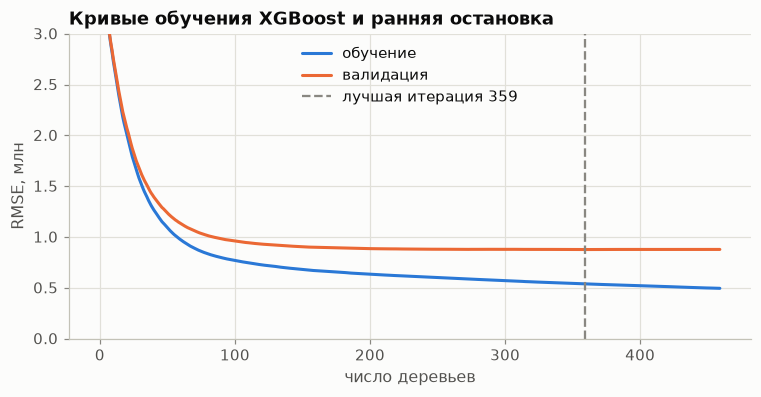

In [4]:
model = xgb.XGBRegressor(n_estimators=5000, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
                         enable_categorical=True, tree_method="hist", early_stopping_rounds=100, eval_metric="rmse")
with ex.timer("обучение"):
    model.fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[tr], y[tr]), (X.iloc[va], y[va])], verbose=False)  # остановка — по последней
p = model.predict(X.iloc[te])
print(f"   лучшая итерация {model.best_iteration} (деревьев в модели {model.get_booster().num_boosted_rounds()})")
print(f"   тест: RMSE {rmse(y[te], p):.3f} млн, средняя относительная ошибка {mape(y[te], p):.1%}")
ex.note("Категории (район, ремонт) и пропуски (кухня) XGBoost принимает сам — без кодирования и заполнения.")
curves = model.evals_result()
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(curves["validation_0"]["rmse"], color=ROLE["train"], lw=2, label="обучение")
ax.plot(curves["validation_1"]["rmse"], color=ROLE["valid"], lw=2, label="валидация")
ax.axvline(model.best_iteration, color=ROLE["truth"], ls="--", lw=1.5, label=f"лучшая итерация {model.best_iteration}")
ax.set(xlabel="число деревьев", ylabel="RMSE, млн", ylim=(0, 3), title="Кривые обучения XGBoost и ранняя остановка")
ax.legend()
ex.finish(fig, "11_learning_curves")

## Этап 4. Цены распределены с длинным хвостом — обучаем на log(цены)

In [5]:
m_log = xgb.XGBRegressor(n_estimators=5000, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8,
                         enable_categorical=True, tree_method="hist", early_stopping_rounds=100)
m_log.fit(X.iloc[tr], np.log(y[tr]), eval_set=[(X.iloc[va], np.log(y[va]))], verbose=False)
p_log = np.exp(m_log.predict(X.iloc[te]))
print(f"   тест: RMSE {rmse(y[te], p_log):.3f} млн, относительная ошибка {mape(y[te], p_log):.1%}")
ex.note("""Мультипликативная цена (площадь × цена м² × множители) в логарифмах становится суммой. Здесь это дало небольшое
улучшение; на данных с более длинным хвостом цен разница обычно больше. Предел точности — шум 8%: средняя
относительная ошибка идеальной модели около 6.4%, так что 7% — близко к потолку.
Прогноз exp(·) оценивает медиану, а не среднее: при шуме 8% разница с средним ≈ 0.3%.""")

   тест: RMSE 0.857 млн, относительная ошибка 7.1%


> ▸ **Вывод.** Мультипликативная цена (площадь × цена м² × множители) в логарифмах становится суммой. Здесь это дало небольшое улучшение; на данных с более длинным хвостом цен разница обычно больше. Предел точности — шум 8%: средняя относительная ошибка идеальной модели около 6.4%, так что 7% — близко к потолку. Прогноз exp(·) оценивает медиану, а не среднее: при шуме 8% разница с средним ≈ 0.3%.

## Этап 5. Нативный интерфейс: DMatrix + xgb.train — то же самое, но с полным контролем

In [6]:
dtr = xgb.DMatrix(X.iloc[tr], label=np.log(y[tr]), enable_categorical=True)
dva = xgb.DMatrix(X.iloc[va], label=np.log(y[va]), enable_categorical=True)
dte = xgb.DMatrix(X.iloc[te], enable_categorical=True)
params = {"eta": 0.05, "max_depth": 6, "subsample": 0.8, "colsample_bytree": 0.8, "tree_method": "hist", "eval_metric": "rmse"}
bst = xgb.train(params, dtr, num_boost_round=5000, evals=[(dva, "val")], early_stopping_rounds=100, verbose_eval=False)
p_nat = np.exp(bst.predict(dte, iteration_range=(0, bst.best_iteration + 1)))
print(f"   лучшая итерация {bst.best_iteration}; RMSE {rmse(y[te], p_nat):.3f} млн")
ex.note("В нативном API прогноз лучшей итерации нужно запросить явно: iteration_range=(0, best_iteration + 1).")

   лучшая итерация 361; RMSE 0.857 млн


> ▸ **Вывод.** В нативном API прогноз лучшей итерации нужно запросить явно: iteration\_range=(0, best\_iteration + 1).

## Этап 6. Важности (gain против weight) и вклады признаков для одной квартиры

In [7]:
gain = bst.get_score(importance_type="gain")
weight = bst.get_score(importance_type="weight")
print("   признак        gain   разбиений")
for f in sorted(gain, key=gain.get, reverse=True):
    print(f"   {f:12s} {gain[f]:8.3f} {int(weight[f]):8d}")
ex.note("У района больше всего разбиений, но по среднему выигрышу он лишь третий: число разбиений — плохая мера важности.")
contrib = bst.predict(dte, pred_contribs=True, iteration_range=(0, bst.best_iteration + 1))
i = 0
print(f"   квартира {i}: " + ", ".join(f"{c}={X.iloc[te[i]][c]}" for c in ["площадь", "район", "ремонт", "до_центра_км"]))
top = np.argsort(-np.abs(contrib[i, :-1]))[:4]
print("   главные вклады в log(цены): " + ", ".join(f"{X.columns[j]} {contrib[i, j]:+.3f}" for j in top)
      + f"; база {contrib[i, -1]:.3f}")
assert abs(contrib[i].sum() - bst.predict(dte, output_margin=True, iteration_range=(0, bst.best_iteration + 1))[i]) < 1e-3

   признак        gain   разбиений
   площадь         2.665     4375
   комнаты         2.250      763
   район           0.712     5406
   до_центра_км    0.621     4385
   ремонт          0.529     1599
   парковка        0.130      459
   год             0.125     3530
   кухня           0.124     3368
   этаж            0.044     2220
   этажность       0.036     1011


> ▸ **Вывод.** У района больше всего разбиений, но по среднему выигрышу он лишь третий: число разбиений — плохая мера важности.

   квартира 0: площадь=33.5, район=район_03, ремонт=без ремонта, до_центра_км=6.03
   главные вклады в log(цены): площадь -0.375, район -0.295, ремонт -0.137, до_центра_км +0.053; база 2.065


## Этап 7. Сохранение в JSON и загрузка

In [8]:
with tempfile.TemporaryDirectory() as d:
    path = Path(d) / "houses.json"
    bst.save_model(path)
    loaded = xgb.Booster()
    loaded.load_model(path)
    same = np.allclose(loaded.predict(dte, iteration_range=(0, bst.best_iteration + 1)), np.log(p_nat))
    print(f"   размер файла {path.stat().st_size / 1024:.0f} КБ; прогнозы после загрузки совпадают: {same}")
assert same
ex.done()

   размер файла 3202 КБ; прогнозы после загрузки совпадают: True
Готово за 2.9 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Обучите модели с `max_depth=4` и 8 — как меняются лучшая итерация и ошибка?
2. Добавьте в таблицу важность по покрытию (`importance_type="cover"`) и сравните с gain и weight.
3. Сохраните модель в бинарный формат .ubj и сравните размер файла с JSON.

## Что дальше

- **Теория в курсе:** [9.1 «XGBoost на практике»](../../../lessons/lesson_9_1/README.md), [8 «XGBoost изнутри»](../../../lessons/lesson_8/README.md).
- **Предыдущий пример:** [10. Переобучение и ранняя остановка на 300 шумных объектах](../../2_small/notebooks/10_overfitting_early_stopping.ipynb)
- **Следующий пример:** [12. LightGBM от начала до конца: отклик клиентов, 50 000 объектов, редкий класс](12_lightgbm_complete.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)